In [25]:
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, r2_score

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
DATA = Path("datasets")

concrete_data = pd.read_csv(DATA/ "concrete_data.csv")

In [5]:
concrete_data

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


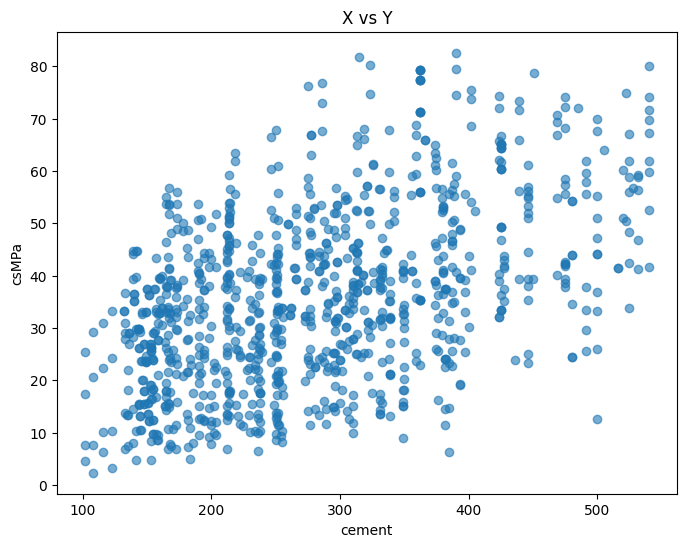

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    concrete_data['cement'],
    concrete_data['csMPa'],
    alpha=0.6
)

ax.set_title('X vs Y')
ax.set_xlabel('cement')
ax.set_ylabel('csMPa')

plt.show()

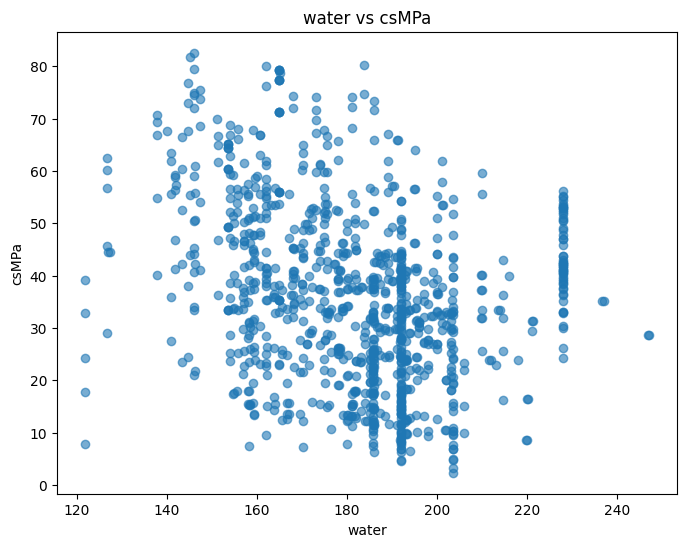

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    concrete_data['water'],
    concrete_data['csMPa'],
    alpha=0.6
)

ax.set_title('water vs csMPa')
ax.set_xlabel('water')
ax.set_ylabel('csMPa')

plt.show()

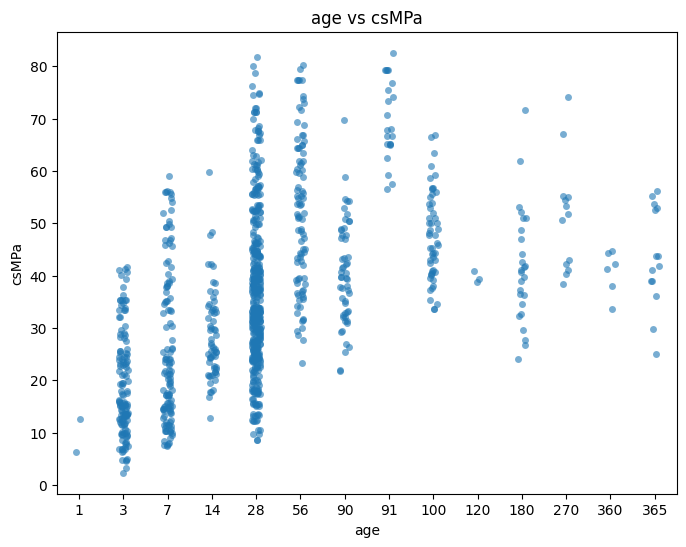

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.stripplot(
    x='age',
    y='csMPa',
    data = concrete_data,
    alpha=0.6
)

ax.set_title('age vs csMPa')
ax.set_xlabel('age')
ax.set_ylabel('csMPa')

plt.show()

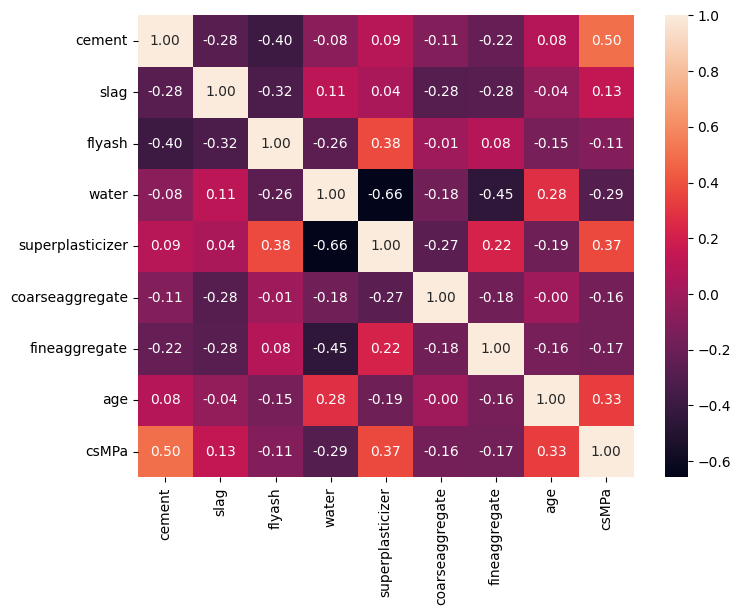

In [13]:
fig, ax = plt.subplots(figsize=(8,6))

sns.heatmap(concrete_data.corr(), annot=True, fmt=".2f")

plt.show()

In [14]:
X = concrete_data.drop(columns='csMPa')
y = concrete_data['csMPa']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [22]:
bag_reg = BaggingRegressor(
    DecisionTreeRegressor(),
    n_estimators=500,
    bootstrap=False, #False to pasting, True to bagging
    max_samples = 1.0,
    n_jobs=-1
)

In [23]:
bag_reg.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeRegressor()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",500
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",1.0
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",False
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [24]:
y_pred = bag_reg.predict(X_test)

In [30]:
r2_score(y_test, y_pred)

# Model wyjasnia 85% zmienności zmiennej docelowej (y).
# 85% wariancji wytrzymałości betonu (MPa) jest wyjaśnione przez cechy wejściowe
# 15% pozostaje niewyjasnione (szum, brakujące zmienne)

0.8017432516889115

In [34]:
pd.DataFrame(
    {'actual': y_test,
     'predict': y_pred}
)

,actual,predict
241,24.54,30.66470
572,13.09,15.69000
733,33.61,32.72000
260,25.37,27.74574
130,74.70,80.20000
...,...,...
553,25.42,21.92000
95,49.20,49.20000
557,17.24,15.69000
109,55.90,44.90000


In [ ]:
bag_reg = BaggingRegressor(
    DecisionTreeRegressor(),
    n_estimators=500,
    bootstrap=True, #False to pasting, True to bagging
    max_samples = 0.8, # 80% danyhc ejst brane do modelu
    n_jobs=-1,
    oob_score=True # out_of_bag walidowane tymi danymi , które nie były brane pod uwagę
)

In [38]:
bag_reg.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeRegressor()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",500
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.8
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",True
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [39]:
y_pred = bag_reg.predict(X_test)

In [40]:
r2_score(y_test, y_pred)

0.9075597337331562

In [ ]:
bag_reg = BaggingRegressor(
    DecisionTreeRegressor(),
    n_estimators=500,
    bootstrap=False, #False to pasting, True to bagging
    max_samples = 1.0, # 80% danyhc ejst brane do modelu
    bootstrap_features=True, #każde drzewo dostanie losowy podzbiór cech
    max_features=0.8, #bierze max 80% feature
    n_jobs=-1,
   
)

In [42]:
bag_reg.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeRegressor()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",500
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",1.0
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",0.8
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",False
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",True
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [43]:
y_pred = bag_reg.predict(X_test)

In [44]:
r2_score(y_test, y_pred)

0.7758008472076665

In [54]:
bag_reg = BaggingRegressor(
    DecisionTreeRegressor(),
    n_estimators=300,
    bootstrap=True, #False to pasting, True to bagging
    max_samples = 0.7, # 80% danych jest brane do modelu
    bootstrap_features=False, #każde drzewo dostanie losowy podzbiór cech
    max_features=1.0, #bierze max 80% feature
    n_jobs=-1,
    oob_score=True,
    random_state=42
   
)

bag_reg.fit(X_train, y_train)
y_pred = bag_reg.predict(X_test)

In [55]:
r2_score(y_test, y_pred)

0.903927083940661

In [59]:
from sklearn.model_selection import GridSearchCV, KFold

In [ ]:
bag_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    bootstrap=True, #False to pasting, True to bagging
    n_jobs=-1,
    random_state=42
   
)

param_grid={
    "n_estimators": [200, 300, 500],
    "max_samples": [0.6, 0.7, 0.8],
    "estimator__max_depth": [6, 8, 10, 12, None],
    "estimator__min_samples_leaf": [1, 3, 5, 10],
    "estimator__min_samples_split": [2 ,5, 10, 20]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid=GridSearchCV(
    estimator=bag_reg,
    param_grid=param_grid,
    scoring='r2',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best CV R2:", grid.best_score_)
print("Best params:", grid.best_params_)

best_model = grid.best_estimator_

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
